# Credit Card Fraud Detection with Deep Learning

This project compares two deep learning approaches for detecting fraudulent credit card transactions in tabular data:

1. A fully connected deep neural network (DNN)
2. A 1D convolutional neural network (CNN)

The objective is to evaluate which architecture is better suited for this classification task using metrics such as AUC and accuracy, and to discuss the practical implications for fraud analytics and risk detection.


## 1. Environment Setup and Imports

In [25]:
# Uncomment to install TensorFlow
# !pip install tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping

## 2. Load and Inspect the Dataset

Load `creditcard.csv` and look at the top rows:

In [18]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Check how many are normal vs. fraud:

In [19]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

## 3. Data Preparation

- Split data into 80% train and 20% test
- Scale features so the network learns better

In [20]:
X = df.drop('Class', axis=1).values
y = df['Class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## 4. Build a Fully Connected Deep Neural Network

Stack layers of neurons with dropout:

In [21]:
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid'),
])
dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
es = EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)
history = dnn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50, batch_size=2048,
    callbacks=[es], verbose=1
)

Epoch 1/50


C:\Users\Chris\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.1838 - loss: 0.2597 - val_AUC: 0.5808 - val_loss: 0.0174
Epoch 2/50
87/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.6464 - loss: 0.0196

C:\Users\Chris\AppData\Roaming\Python\Python312\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.6517 - loss: 0.0194 - val_AUC: 0.8993 - val_loss: 0.0070
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.8761 - loss: 0.0088 - val_AUC: 0.9027 - val_loss: 0.0052
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.8836 - loss: 0.0068 - val_AUC: 0.9030 - val_loss: 0.0045
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.9072 - loss: 0.0062 - val_AUC: 0.9031 - val_loss: 0.0042
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.9145 - loss: 0.0044 - val_AUC: 0.9091 - val_loss: 0.0040
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.9404 - loss: 0.0041 - val_AUC: 0.9271 - val_loss: 0.0039
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.9407 - loss: 0.0040 - val_AUC: 0.9271 - val_loss: 0.0038
Epoch 9/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.9464 - loss: 0.0039 - val_AUC: 0.9273 - val_loss: 0.0038
Epoch 10/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.9276 - loss: 0.0039 - v

## 5. Evaluate the DNN

Check AUC and accuracy, then plot the ROC curve:

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 369us/step
DNN AUC: 0.9737, Accuracy: 0.9995


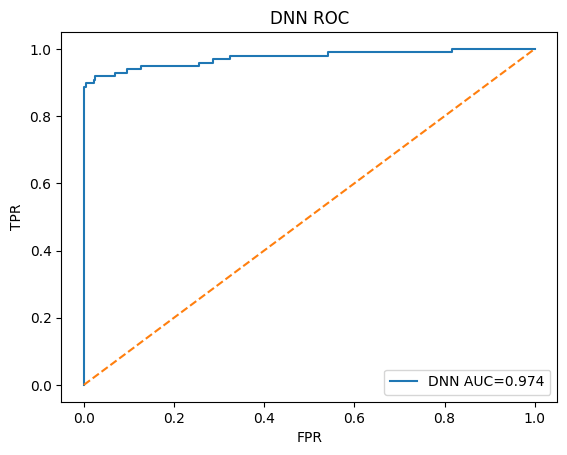

In [22]:
y_prob = dnn.predict(X_test).ravel()
auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, (y_prob > 0.5).astype(int))
print(f'DNN AUC: {auc:.4f}, Accuracy: {acc:.4f}')
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'DNN AUC={auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('DNN ROC')
plt.legend(); plt.show()

## 6. Build a 1D CNN for Tabular Classification

Reshape data and use convolution layers:

In [23]:
X_train_c = X_train.reshape(-1, X_train.shape[1], 1)
X_test_c  = X_test.reshape(-1, X_test.shape[1], 1)

cnn = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(X_train.shape[1],1)),
    MaxPooling1D(2), Dropout(0.3),
    Conv1D(16, 3, activation='relu'),
    MaxPooling1D(2), Dropout(0.2),
    Flatten(), Dense(16, activation='relu'),
    Dropout(0.2), Dense(1, activation='sigmoid'),
])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
es_c = EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)
history_c = cnn.fit(
    X_train_c, y_train,
    validation_split=0.2, epochs=50, batch_size=2048,
    callbacks=[es_c], verbose=1
)

Epoch 1/50


C:\Users\Chris\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - AUC: 0.2032 - loss: 0.2315 - val_AUC: 0.3211 - val_loss: 0.0407
Epoch 2/50
20/90 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.3737 - loss: 0.0409

C:\Users\Chris\AppData\Roaming\Python\Python312\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - AUC: 0.3599 - loss: 0.0430 - val_AUC: 0.3781 - val_loss: 0.0266
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - AUC: 0.3934 - loss: 0.0284 - val_AUC: 0.6369 - val_loss: 0.0141
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - AUC: 0.6505 - loss: 0.0153 - val_AUC: 0.8889 - val_loss: 0.0062
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.8650 - loss: 0.0079 - val_AUC: 0.9026 - val_loss: 0.0051
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - AUC: 0.8647 - loss: 0.0079 - val_AUC: 0.9034 - val_loss: 0.0048
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AUC: 0.8584 - loss: 0.0066 - val_AUC: 0.9033 - val_loss: 0.0044
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AUC: 0.8898 - loss: 0.0054 - val_AUC: 0.9154 - val_loss: 0.0042
Epoch 9/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AUC: 0.9242 - loss: 0.0047 - val_AUC: 0.9154 - val_loss: 0.0039
Epoch 10/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - AUC: 0.9050 - loss: 0.005

## 7. Evaluate the CNN

AUC, accuracy, and ROC plot:

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
CNN AUC: 0.9700, Accuracy: 0.9994


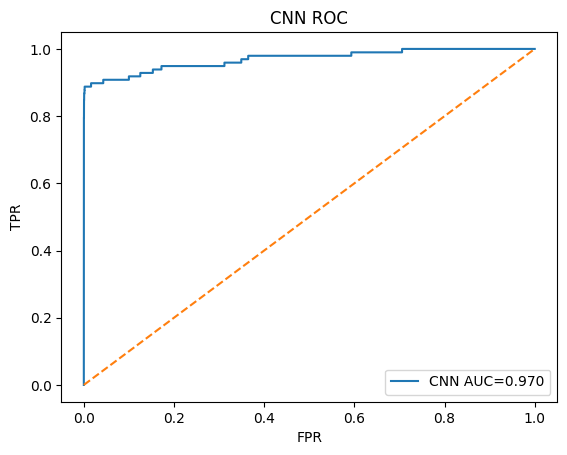

In [24]:
y_prob_c = cnn.predict(X_test_c).ravel()
auc_c = roc_auc_score(y_test, y_prob_c)
acc_c = accuracy_score(y_test, (y_prob_c > 0.5).astype(int))
print(f'CNN AUC: {auc_c:.4f}, Accuracy: {acc_c:.4f}')
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_c)
plt.plot(fpr_c, tpr_c, label=f'CNN AUC={auc_c:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('CNN ROC')
plt.legend(); plt.show()

## 8. Project Summary and Takeaways

This project compared a fully connected deep neural network and a 1D convolutional neural network for credit card fraud detection on tabular transaction data.

### Key takeaways
- The DNN delivered slightly stronger performance in this workflow.
- For structured, tabular transaction features, a dense architecture can be a more natural fit than a CNN.
- AUC is especially important in fraud detection because it helps assess how well the model separates fraudulent from legitimate transactions across thresholds.

### Why this matters
Fraud detection problems are typically highly imbalanced and operationally sensitive. Even a modest improvement in classification quality can reduce false positives, improve analyst efficiency, and strengthen risk controls.

### Next steps
Future improvements could include:
- Testing tree-based baselines alongside deep learning models
- Tuning class weighting or threshold selection for imbalanced data
- Adding precision, recall, F1-score, and confusion-matrix analysis
- Exploring explainability techniques for model interpretation
